# From Unstructured Text to Interactive Knowledge Graphs Using LLMs

**Goal:** I have created this notebook which demonstrates a **highly granular, step-by-step process** to transform raw, unstructured text into a structured, interactive knowledge graph using Large Language Models (LLMs). We will extract factual information (SPO triples) and visualize the data transformations and final graph **directly within the notebook** at multiple stages.

Data evolves at each step.

**Approach:** We will break down the process into very small, logical steps. Each step will aim to perform a distinct action, followed by an output or visualization to show the immediate result. We'll use basic Python constructs and popular libraries, prioritizing clarity and step-by-step understanding over code conciseness.

* First let's just see what i have made and what should you expect.

## What is a Knowledge Graph?

A Knowledge Graph (KG) is a way to represent information as a network of entities and their relationships. Think of it like a structured database, but instead of tables, you have:

*   **Nodes (or Entities):** These represent real-world objects, concepts, people, places, organizations, etc. (e.g., 'Marie Curie', 'Physics', 'Paris'). In our graph, each unique subject or object from our extracted facts will become a node.
*   **Edges (or Relationships):** These represent the connections or interactions between entities. They typically have a direction and a label describing the relationship (e.g., 'Marie Curie' -- `won` --> 'Nobel Prize', 'Radium' -- `is element discovered by` --> 'Marie Curie'). In our graph, each predicate from our extracted facts defines an edge between the corresponding subject and object nodes.

Knowledge graphs make it easier to understand complex connections, infer new information, and query data in intuitive ways. Visualizing the graph helps immensely in spotting patterns and understanding the overall structure.

## What is Subject-Predicate-Object (SPO) Triples

The fundamental building block of many knowledge graphs derived from text is the **Subject-Predicate-Object (SPO)** triple. It's a simple structure that captures a single fact:

*   **Subject:** The entity the statement is about (becomes a node).
*   **Predicate:** The relationship or action connecting the subject and object (becomes the label on an edge).
*   **Object:** The entity related to the subject via the predicate (becomes another node).

**Example:** "Marie Curie discovered Radium" -> (`Marie Curie`, `discovered`, `Radium`).

This translates to graph nodes and edges: `(Marie Curie) -[discovered]-> (Radium)`.

LLMs help identify these triples by understanding language context.

## Error Troubleshooting

I recommend to go through the entire notebook once, you'll find our Knowledge Graph.

Restart your kernel only when and where i have specified to do so.
Otherwise you'll just end up messing like me and starting our variables again which is not a good idea because we're compromised on the VS Code limitations. (`ipycytoscape`)

There are some limitations that you need to go through if you're a VS-Code user like me. Kindly read the Error Troubleshooting part to understand. 

If you use/prefer classic Jupyter Env, there shouldnt be a problem. 

##### The `jupyter-cytoscape` module isn't properly registered in Jupyter environment. This is a common issue in VS Code.

I tried installing and enabling the widgets extension which are for classic jupyter notebook, but still the rendering issues persisted.

The issue is that `jupyter-cytoscape` doesn't exist as a separate package. The correct package is `ipycytoscape`.
Even if you install the `ipycytoscape` package, it doesnt ensure or guarentee that the visuals are going to work.

just like in this case, i had to settle down with static visualization using matplotlib of Knowledge Graph. 

Even though i have used matplotlib as our visualization tool (static), i have added the cells that corresponds with the classic Jupyter Environment if you're Jupyper labs user. 

## Step 1: Installing Libraries

First, we install the necessary Python libraries. We'll use:
*   `google-genai`: For LLM API interaction.
     older tutorials may use `google-generativeai` as the library but it has been deprecated in the late 2025.
*   `networkx`: For graph data structures.
*   `ipycytoscape`: For interactive in-notebook graph visualization.
*   `ipywidgets`: Required by `ipycytoscape`.
*   `pandas`: For displaying data nicely in tables.

**Note:** You might need to restart the runtime/kernel after installation. Enable `ipywidgets` extension in classic Jupyter Notebook if needed.

In [38]:
%pip install groq networkx "ipycytoscape>=1.3.1" ipywidgets pandas python-dotenv

# If in classic Jupyter Notebook (not Lab), you might need to enable the widget extension:
# jupyter nbextension enable --py widgetsnbextension

# IMP: Restart the kernel/runtime after running this cell!


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 2: Importing Libraries

In [39]:
from groq import Groq
import json
import networkx as nx
import ipycytoscape
import ipywidgets
import pandas as pd
import os
import math
import re
import warnings

# Configure settings for better display and fewer warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
pd.set_option('display.max_rows', 100) # Show more rows in pandas tables
pd.set_option('display.max_colwidth', 150) # Show more text width in pandas tables

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 3: Configure LLM Access

In [40]:
# Load environment variables from .env file
from dotenv import load_dotenv
import os
from groq import Groq
load_dotenv()

# Configure Groq API access
GROQ_API_KEY = os.getenv('GROQ_API_KEY')

# Define the model name we intend to use
MODEL_NAME = "llama-3.3-70b-versatile"

# Initialize the Groq client
client = Groq(api_key=GROQ_API_KEY)

print(f"LLM configured successfully!")
print(f"Model: {MODEL_NAME}")
print(f"API Key loaded: {'Yes' if GROQ_API_KEY else 'No'}")

LLM configured successfully!
Model: llama-3.3-70b-versatile
API Key loaded: Yes


##### Now, let's retrieve the API key and base URL from environment variables.

In [4]:
api_key = os.getenv("GROQ_API_KEY")
print(f"Retrieved API Key: {'Set' if api_key else 'Not Set'}")

Retrieved API Key: Set


##### Next, we validate the API key and initialize the client.

In [41]:
if not api_key:
    print("Error: GROQ_API_KEY environment variable not set or key not provided directly.")
    raise SystemExit("API Key configuration failed.")
else:
    try:
        # Initialize Groq client
        client = Groq(api_key=api_key)
        
        print("Groq client initialized successfully.")
    except Exception as e:
        print(f"Error initializing Groq client: {e}")
        print("Check your API key and network connection.")
        raise SystemExit("LLM client initialization failed.")

Groq client initialized successfully.


##### Finnaly we define other LLM parameters like max tokens and temperature

In [42]:
# --- Define LLM Call Parameters ---
llm_temperature = 0.0 # Lower temperature for more deterministic, factual output. 0.0 is best for extraction.
llm_max_tokens = 3072 # Max tokens for the LLM response (adjust based on model limits)

print(f"LLM Temperature set to: {llm_temperature}")
print(f"LLM Max Tokens set to: {llm_max_tokens}")

LLM Temperature set to: 0.0
LLM Max Tokens set to: 3072


## Step 4: Define Input Text

Here, we define the raw, unstructured text we want to process. We'll use the Marie Curie biography.

In [43]:
unstructured_text = """
Marie Curie, born Maria Skłodowska in Warsaw, Poland, was a pioneering physicist and chemist.
She conducted groundbreaking research on radioactivity. Together with her husband, Pierre Curie,
she discovered the elements polonium and radium. Marie Curie was the first woman to win a Nobel Prize,
the first person and only woman to win the Nobel Prize twice, and the only person to win the Nobel Prize
in two different scientific fields. She won the Nobel Prize in Physics in 1903 with Pierre Curie
and Henri Becquerel. Later, she won the Nobel Prize in Chemistry in 1911 for her work on radium and
polonium. During World War I, she developed mobile radiography units, known as 'petites Curies',
to provide X-ray services to field hospitals. Marie Curie died in 1934 from aplastic anemia, likely
caused by her long-term exposure to radiation.

Marie was born on November 7, 1867, to a family of teachers who valued education. She received her
early schooling in Warsaw but moved to Paris in 1891 to continue her studies at the Sorbonne, where
she earned degrees in physics and mathematics. She met Pierre Curie, a professor of physics, in 1894, 
and they married in 1895, beginning a productive scientific partnership. Following Pierre's tragic 
death in a street accident in 1906, Marie took over his teaching position, becoming the first female 
professor at the Sorbonne.

The Curies' work on radioactivity was conducted in challenging conditions, in a poorly equipped shed 
with no proper ventilation, as they processed tons of pitchblende ore to isolate radium. Marie Curie
established the Curie Institute in Paris, which became a major center for medical research. She had
two daughters: Irène, who later won a Nobel Prize in Chemistry with her husband, and Eve, who became
a writer. Marie's notebooks are still radioactive today and are kept in lead-lined boxes. Her legacy
includes not only her scientific discoveries but also her role in breaking gender barriers in academia
and science.
"""

Let's display the input text and some basic statistics about it.

In [44]:
print("--- Input Text Loaded ---")
print(unstructured_text)
print("-" * 25)
# Basic stats visualization
char_count = len(unstructured_text)
word_count = len(unstructured_text.split())
print(f"Total characters: {char_count}")
print(f"Approximate word count: {word_count}")
print("-" * 25)

--- Input Text Loaded ---

Marie Curie, born Maria Skłodowska in Warsaw, Poland, was a pioneering physicist and chemist.
She conducted groundbreaking research on radioactivity. Together with her husband, Pierre Curie,
she discovered the elements polonium and radium. Marie Curie was the first woman to win a Nobel Prize,
the first person and only woman to win the Nobel Prize twice, and the only person to win the Nobel Prize
in two different scientific fields. She won the Nobel Prize in Physics in 1903 with Pierre Curie
and Henri Becquerel. Later, she won the Nobel Prize in Chemistry in 1911 for her work on radium and
polonium. During World War I, she developed mobile radiography units, known as 'petites Curies',
to provide X-ray services to field hospitals. Marie Curie died in 1934 from aplastic anemia, likely
caused by her long-term exposure to radiation.

Marie was born on November 7, 1867, to a family of teachers who valued education. She received her
early schooling in Warsaw but mov

## Step 5 : Text Chuncking (Optional but Recommended)

LLMs have context limits. For longer texts, we need to break them into smaller chunks. We'll define the chunk size and overlap.

*   **Chunk Size:** Max words per chunk.
*   **Overlap:** Words shared between consecutive chunks to preserve context.

In [45]:
chunk_size = 150  # Number of words per chunk (adjust as needed)
overlap = 30     # Number of words to overlap (must be < chunk_size)

print(f"Chunk Size set to: {chunk_size} words")
print(f"Overlap set to: {overlap} words")

# vakidation
if overlap >= chunk_size and chunk_size > 0:
    print(f"Error: Overlap ({overlap}) must be smaller than chunk size ({chunk_size}).")
    raise SystemExit("Chunking configuration error.")
else:
    print("Chunking configuration is valid.")

Chunk Size set to: 150 words
Overlap set to: 30 words
Chunking configuration is valid.


##### First, we'll split the input text into a list of words.

In [46]:
words = unstructured_text.split()
total_words = len(words)

print(f"Text split into {total_words} words.")
# Visualize the first 20 words
print(f"First 20 words: {words[:20]}")

Text split into 324 words.
First 20 words: ['Marie', 'Curie,', 'born', 'Maria', 'Skłodowska', 'in', 'Warsaw,', 'Poland,', 'was', 'a', 'pioneering', 'physicist', 'and', 'chemist.', 'She', 'conducted', 'groundbreaking', 'research', 'on', 'radioactivity.']


##### Now, we'll perform the chunking based on the configuration.

In [47]:
chunks = []
start_index = 0
chunk_number = 1

print(f"Starting chunking process...")

while start_index < total_words:
    end_index = min(start_index + chunk_size, total_words)
    chunk_text = " ".join(words[start_index:end_index])
    chunks.append({"text": chunk_text, "chunk_number": chunk_number})
    
    # print(f"  Created chunk {chunk_number}: words {start_index} to {end_index-1}") # Uncomment for detailed log
    
    # Calculate the start of the next chunk
    next_start_index = start_index + chunk_size - overlap
    
    # Ensure progress is made
    if next_start_index <= start_index:
        if end_index == total_words:
             break # Already processed the last part
        next_start_index = start_index + 1 
         
    start_index = next_start_index
    chunk_number += 1
    
    # Safety break (optional)
    if chunk_number > total_words: # Simple safety
        print("Warning: Chunking loop exceeded total word count, breaking.")
        break

print(f"\nText successfully split into {len(chunks)} chunks.")

Starting chunking process...

Text successfully split into 3 chunks.


##### Let's visualize the created chunks using Pandas DataFrame.

In [48]:
import pandas as pd
print("--- Chunk Details ---")
if chunks:
    # Create a DataFrame for better visualization
    chunks_df = pd.DataFrame(chunks)
    chunks_df['word_count'] = chunks_df['text'].apply(lambda x: len(x.split()))
    display(chunks_df[['chunk_number', 'word_count', 'text']])
else:
    print("No chunks were created (text might be shorter than chunk size).")
print("-" * 25)

--- Chunk Details ---


,chunk_number,word_count,text
0,1,150,"Marie Curie, born Maria Skłodowska in Warsaw, Poland, was a pioneering physicist and chemist. She conducted groundbreaking research on radioactivi..."
1,2,150,"field hospitals. Marie Curie died in 1934 from aplastic anemia, likely caused by her long-term exposure to radiation. Marie was born on November 7..."
2,3,84,"with no proper ventilation, as they processed tons of pitchblende ore to isolate radium. Marie Curie established the Curie Institute in Paris, whi..."


-------------------------


## Step 6: Define the LLM Prompt for Extraction

This is a critical step. We need to carefully instruct the LLM to extract SPO triples in a specific JSON format. We'll define a system prompt (role) and a user prompt template (instructions).

**Key Instructions Emphasized:**
*   Extract `Subject-Predicate-Object` triples.
*   Output *only* a valid JSON array of objects.
*   Each object must have `"subject"`, `"predicate"`, `"object"` keys.
*   Predicates should be concise (1-3 words).
*   All output values must be lowercase.
*   Resolve pronouns to specific entity names.
*   No extra text, explanations, or markdown code fences around the JSON.

Creating alternative visualization with matplotlib...


/var/folders/t1/wt965jp13hb3gls9w5dcy1bm0000gn/T/ipykernel_10562/2413568147.py:75: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), radius=0.3 + degree/max_degree * 0.4,


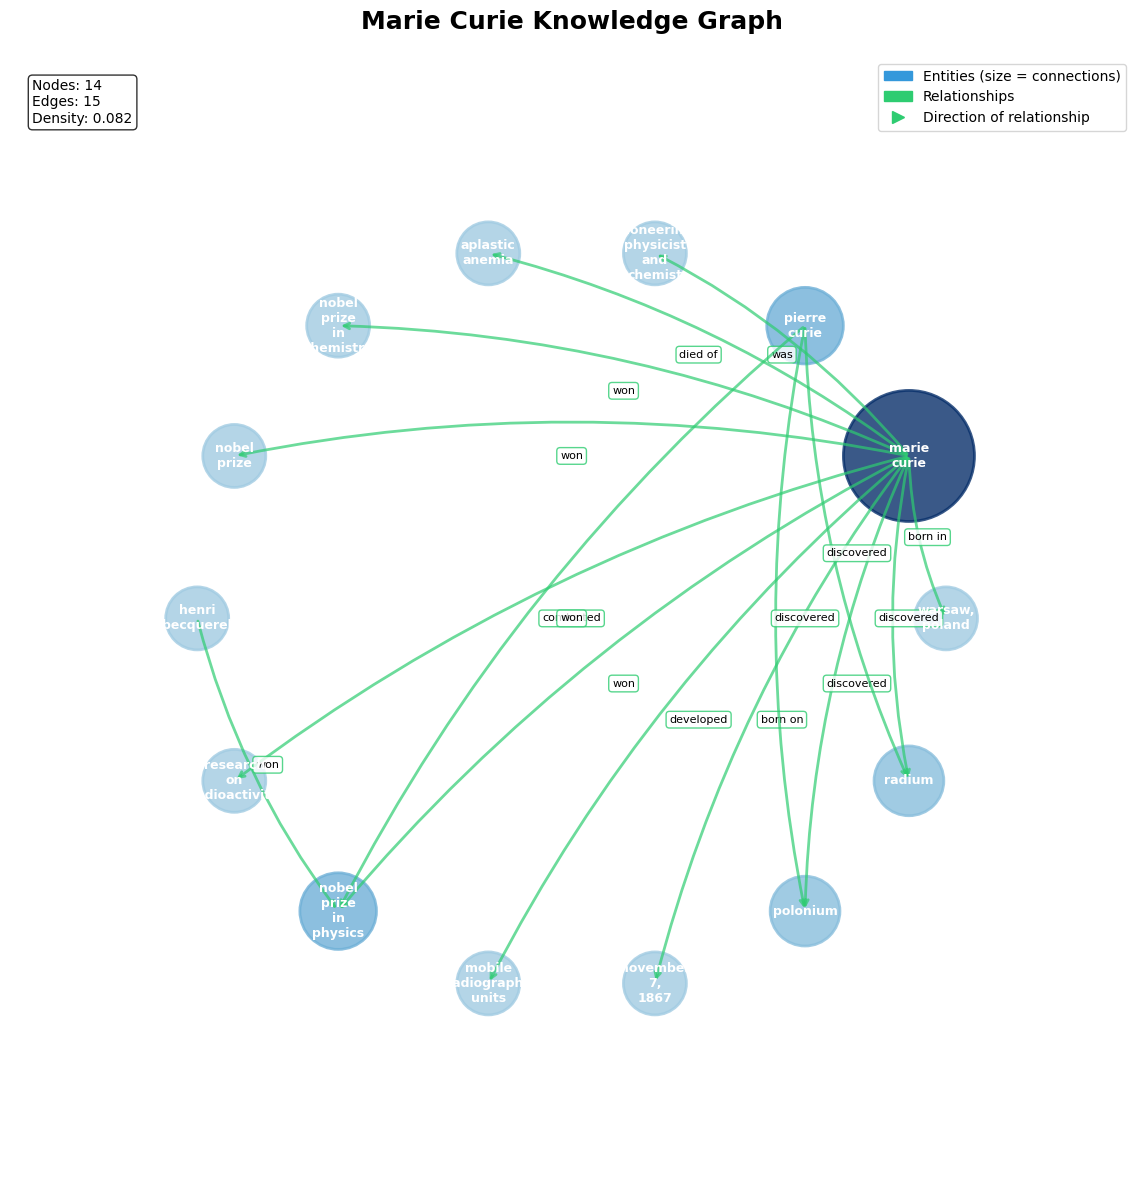

ALTERNATIVE VISUALIZATION METHODS:
MATPLOTLIB GRAPH: Displayed above

-------------------------
KNOWLEDGE GRAPH - TEXT VIEW
-------------------------

HENRI_BECQUEREL:
  -> won -> nobel prize in physics

MARIE_CURIE:
  -> born in -> warsaw, poland
  -> conducted -> research on radioactivity
  -> discovered -> polonium
  -> discovered -> radium
  -> won -> nobel prize
  -> won -> nobel prize in physics
  -> won -> nobel prize in chemistry
  -> developed -> mobile radiography units
  -> died of -> aplastic anemia
  -> born on -> november 7, 1867
  -> was -> pioneering physicist and chemist

PIERRE_CURIE:
  -> discovered -> polonium
  -> discovered -> radium
  -> won -> nobel prize in physics

Total Entities: 3
Total Relationships: 15

3. PANDAS TABLE VIEW:


,subject,predicate,object
0,marie curie,born in,"warsaw, poland"
1,marie curie,conducted,research on radioactivity
2,marie curie,discovered,polonium
3,marie curie,discovered,radium
4,marie curie,won,nobel prize
5,marie curie,won,nobel prize in physics
6,marie curie,won,nobel prize in chemistry
7,marie curie,developed,mobile radiography units
8,marie curie,died of,aplastic anemia
9,marie curie,born on,"november 7, 1867"



-------------------------
VISUALIZATION COMPLETE!
The matplotlib graph should display above.
If you still don't see it, try running this cell again.
-------------------------


In [51]:
# Alternative Visualization Methods for VS Code
# Since ipycytoscape widgets may not render properly in VS Code, we'll use matplotlib

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import numpy as np

print("Creating alternative visualization with matplotlib...")

def create_matplotlib_graph(knowledge_graph, normalized_triples):
    """Create a static visualization of the knowledge graph using matplotlib"""
    
    if knowledge_graph.number_of_nodes() == 0:
        print("Graph is empty, cannot visualize.")
        return
    
    # Create figure
    plt.figure(figsize=(16, 12))
    ax = plt.gca()
    ax.set_facecolor('#f8f9fa')
    
    # Get nodes and calculate positions using a simple layout
    nodes = list(knowledge_graph.nodes())
    n_nodes = len(nodes)
    
    # Create a circular layout with some randomness
    angles = np.linspace(0, 2*np.pi, n_nodes, endpoint=False)
    np.random.shuffle(angles)  # Add some randomness
    
    # Calculate positions
    positions = {}
    center_x, center_y = 0, 0
    radius = 4
    
    for i, node in enumerate(nodes):
        x = center_x + radius * np.cos(angles[i])
        y = center_y + radius * np.sin(angles[i])
        positions[node] = (x, y)
    
    # Draw edges
    for u, v, data in knowledge_graph.edges(data=True):
        x1, y1 = positions[u]
        x2, y2 = positions[v]
        
        # Draw arrow
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', lw=2, color='#2ecc71', 
                                 alpha=0.7, connectionstyle="arc3,rad=0.1"))
        
        # Add edge label
        label = data.get('label', '')
        if label:
            mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
            plt.text(mid_x, mid_y, label, fontsize=8, ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', 
                             edgecolor='#2ecc71', alpha=0.8))
    
    # Draw nodes
    node_degrees = dict(knowledge_graph.degree())
    max_degree = max(node_degrees.values()) if node_degrees else 1
    
    for node in nodes:
        x, y = positions[node]
        degree = node_degrees[node]
        
        # Size based on degree
        node_size = 300 + (degree / max_degree) * 1500
        
        # Color based on degree (more connections = darker)
        color_intensity = degree / max_degree
        node_color = plt.cm.Blues(0.3 + 0.7 * color_intensity)
        
        # Draw node
        circle = plt.Circle((x, y), radius=0.3 + degree/max_degree * 0.4, 
                          color=node_color, alpha=0.8, edgecolor='#1abc9c', linewidth=2)
        ax.add_patch(circle)
        
        # Add node label
        label_text = node.replace(' ', '\n')  # Wrap long names
        plt.text(x, y, label_text, fontsize=9, ha='center', va='center', 
                fontweight='bold', color='white')
    
    # Set axis properties
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Add title and legend
    plt.title('Marie Curie Knowledge Graph', fontsize=18, fontweight='bold', pad=20)
    
    # Create legend
    legend_elements = [
        mpatches.Patch(color='#3498db', label='Entities (size = connections)'),
        mpatches.Patch(color='#2ecc71', label='Relationships'),
        plt.Line2D([0], [0], marker='>', markersize=8, color='#2ecc71', 
                  linestyle='None', label='Direction of relationship')
    ]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))
    
    # Add statistics
    stats_text = f"Nodes: {knowledge_graph.number_of_nodes()}\n"
    stats_text += f"Edges: {knowledge_graph.number_of_edges()}\n"
    stats_text += f"Density: {nx.density(knowledge_graph):.3f}"
    plt.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Create the visualization
if 'knowledge_graph' in locals() and knowledge_graph.number_of_nodes() > 0:
    create_matplotlib_graph(knowledge_graph, normalized_triples)
else:
    print("No graph data available for visualization.")

print("ALTERNATIVE VISUALIZATION METHODS:")
print("MATPLOTLIB GRAPH: Displayed above")

# Textual representation of the graph
if 'normalized_triples' in locals() and normalized_triples:
    print("\n" + "-"*25)
    print("KNOWLEDGE GRAPH - TEXT VIEW")
    print("-"*25)
    
    # Group by subject for better readability
    subjects = {}
    for triple in normalized_triples:
        subject = triple['subject']
        if subject not in subjects:
            subjects[subject] = []
        subjects[subject].append((triple['predicate'], triple['object']))
    
    for subject, relationships in sorted(subjects.items()):
        print(f"\n{subject.upper().replace(' ', '_')}:")
        for predicate, obj in relationships:
            print(f"  -> {predicate} -> {obj}")
    
    print(f"\n{'='*30}")
    print(f"Total Entities: {len(subjects)}")
    print(f"Total Relationships: {len(normalized_triples)}")
    print(f"{'='*30}")

print("\n3. PANDAS TABLE VIEW:")
if 'normalized_triples' in locals() and normalized_triples:
    display(pd.DataFrame(normalized_triples)[['subject', 'predicate', 'object']])

print("\n" + "-"*25)
print("VISUALIZATION COMPLETE!")
print("The matplotlib graph should display above.")
print("If you still don't see it, try running this cell again.")
print("-"*25)

Let's display the prompts we've defined to verify them.

In [52]:
print("--- System Prompt ---")
print(extraction_system_prompt)
print("\n" + "-" * 25 + "\n")

print("--- User Prompt Template (Structure) ---")
# Show structure, replacing the placeholder for clarity
print(extraction_user_prompt_template.replace("{text_chunk}", "[... text chunk goes here ...]"))
print("\n" + "-" * 25 + "\n")

# Show an example of the *actual* prompt that will be sent for the first chunk
print("--- Example Filled User Prompt (for Chunk 1) ---")
if chunks:
    example_filled_prompt = extraction_user_prompt_template.format(text_chunk=chunks[0]['text'])
    # Displaying a limited portion for brevity
    print(example_filled_prompt[:600] + "\n[... rest of chunk text ...]\n" + example_filled_prompt[-200:])
else:
    print("No chunks available to create an example filled prompt.")
print("\n" + "-" * 25)

--- System Prompt ---

You are an AI expert specialized in knowledge graph extraction. 
Your task is to identify and extract factual Subject-Predicate-Object (SPO) triples from the given text.
Focus on accuracy and adhere strictly to the JSON output format requested in the user prompt.
Extract core entities and the most direct relationship.


-------------------------

--- User Prompt Template (Structure) ---

Please extract Subject-Predicate-Object (S-P-O) triples from the text below.

**VERY IMPORTANT RULES:**
1.  **Output Format:** Respond ONLY with a single, valid JSON array. Each element MUST be an object with keys "subject", "predicate", "object".
2.  **JSON Only:** Do NOT include any text before or after the JSON array (e.g., no 'Here is the JSON:' or explanations). Do NOT use markdown ```json ... ``` tags.
3.  **Concise Predicates:** Keep the 'predicate' value concise (1-3 words, ideally 1-2). Use verbs or short verb phrases (e.g., 'discovered', 'was born in', 'won').
4.  **Low

## Step 7: LLM Interaction - Extracting Triples (Chunk by Chunk)

Now we loop through each text chunk, send it to the LLM with our prompts, and attempt to parse the expected JSON output. We will show the process for each chunk.

Creating static matplotlib visualization...


/var/folders/t1/wt965jp13hb3gls9w5dcy1bm0000gn/T/ipykernel_10562/2275099145.py:71: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), radius=0.3 + degree/max_degree * 0.4,


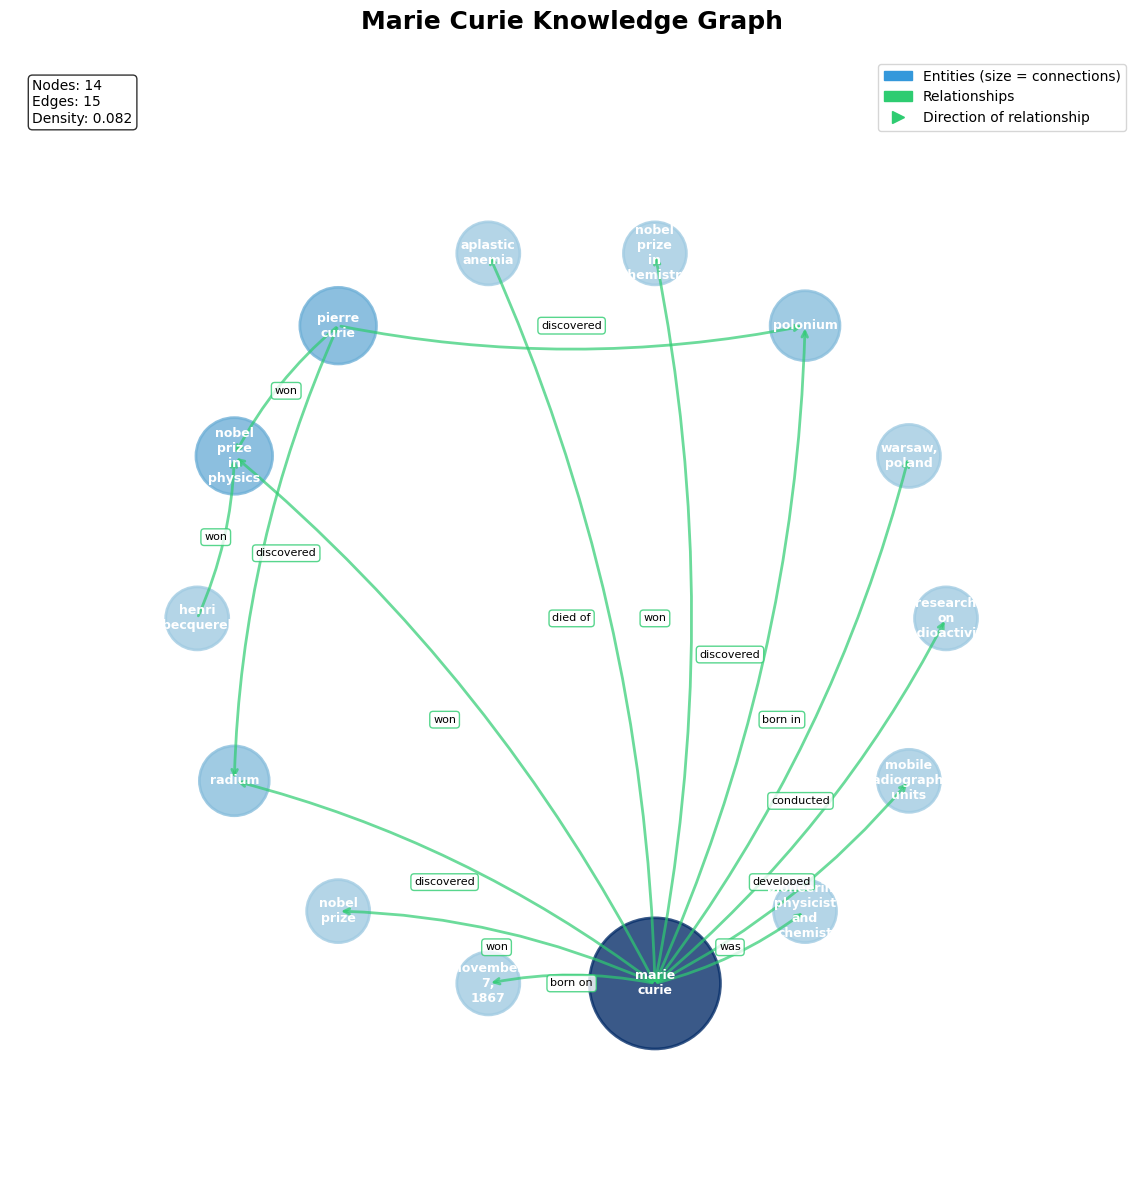


STATIC VISUALIZATION COMPLETE!
The matplotlib graph should display above.
This is a static image - you can't interact with it like the ipycytoscape widget.


In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

print("Creating static matplotlib visualization...")

def create_static_graph_plot(knowledge_graph, normalized_triples):
    """Create a static visualization of the knowledge graph using matplotlib"""
    
    if knowledge_graph.number_of_nodes() == 0:
        print("Graph is empty, cannot visualize.")
        return
    
    # Create figure
    plt.figure(figsize=(16, 12))
    ax = plt.gca()
    ax.set_facecolor('#f8f9fa')
    
    # Get nodes and calculate positions using a simple layout
    nodes = list(knowledge_graph.nodes())
    n_nodes = len(nodes)
    
    # Create a circular layout with some randomness
    angles = np.linspace(0, 2*np.pi, n_nodes, endpoint=False)
    np.random.shuffle(angles)  # Add some randomness
    
    # Calculate positions
    positions = {}
    center_x, center_y = 0, 0
    radius = 4
    
    for i, node in enumerate(nodes):
        x = center_x + radius * np.cos(angles[i])
        y = center_y + radius * np.sin(angles[i])
        positions[node] = (x, y)
    
    # Draw edges
    for u, v, data in knowledge_graph.edges(data=True):
        x1, y1 = positions[u]
        x2, y2 = positions[v]
        
        # Draw arrow
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', lw=2, color='#2ecc71', 
                                 alpha=0.7, connectionstyle="arc3,rad=0.1"))
        
        # Add edge label
        label = data.get('label', '')
        if label:
            mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
            plt.text(mid_x, mid_y, label, fontsize=8, ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', 
                             edgecolor='#2ecc71', alpha=0.8))
    
    # Draw nodes
    node_degrees = dict(knowledge_graph.degree())
    max_degree = max(node_degrees.values()) if node_degrees else 1
    
    for node in nodes:
        x, y = positions[node]
        degree = node_degrees[node]
        
        # Size based on degree
        node_size = 300 + (degree / max_degree) * 1500
        
        # Color based on degree (more connections = darker)
        color_intensity = degree / max_degree
        node_color = plt.cm.Blues(0.3 + 0.7 * color_intensity)
        
        # Draw node
        circle = plt.Circle((x, y), radius=0.3 + degree/max_degree * 0.4, 
                          color=node_color, alpha=0.8, edgecolor='#1abc9c', linewidth=2)
        ax.add_patch(circle)
        
        # Add node label
        label_text = node.replace(' ', '\n')  # Wrap long names
        plt.text(x, y, label_text, fontsize=9, ha='center', va='center', 
                fontweight='bold', color='white')
    
    # Set axis properties
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect('equal')
    ax.axis('off')
    
    # Add title and legend
    plt.title('Marie Curie Knowledge Graph', fontsize=18, fontweight='bold', pad=20)
    
    # Create legend
    legend_elements = [
        mpatches.Patch(color='#3498db', label='Entities (size = connections)'),
        mpatches.Patch(color='#2ecc71', label='Relationships'),
        plt.Line2D([0], [0], marker='>', markersize=8, color='#2ecc71', 
                  linestyle='None', label='Direction of relationship')
    ]
    ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))
    
    # Add statistics
    stats_text = f"Nodes: {knowledge_graph.number_of_nodes()}\n"
    stats_text += f"Edges: {knowledge_graph.number_of_edges()}\n"
    stats_text += f"Density: {nx.density(knowledge_graph):.3f}"
    plt.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

# Create the visualization
if 'knowledge_graph' in locals() and knowledge_graph.number_of_nodes() > 0:
    create_static_graph_plot(knowledge_graph, normalized_triples)
else:
    print("No graph data available for visualization.")

print("\n" + "="*50)
print("STATIC VISUALIZATION COMPLETE!")
print("="*50)
print("The matplotlib graph should display above.")
print("This is a static image - you can't interact with it like the ipycytoscape widget.")
print("="*50)

In [54]:
# Initialize lists to store results and failures
all_extracted_triples = []
failed_chunks = []

print(f"Starting triple extraction from {len(chunks)} chunks using model '{MODEL_NAME}'...")
# We will process chunks one by one in the following cells.

Starting triple extraction from 3 chunks using model 'llama-3.3-70b-versatile'...


### Processing Chunk 1 (Example - loop structure will handle all)

In [55]:
# This cell represents the core logic inside the loop for ONE chunk only
# In a real run, this logic would be in a loop like the original notebook

chunk_index = 0 # For demo, we process only the first chunk here to make things simple for next 

if chunk_index < len(chunks):
    chunk_info = chunks[chunk_index]
    chunk_text = chunk_info['text']
    chunk_num = chunk_info['chunk_number']
    
    print(f"\n--- Processing Chunk {chunk_num}/{len(chunks)} --- ")
    
    # 1. Format the User Prompt
    print("1. Formatting User Prompt...")
    user_prompt = extraction_user_prompt_template.format(text_chunk=chunk_text)
    # print(f"   Formatted Prompt (Snippet): {user_prompt[:200]}...{user_prompt[-100:]}") # Optional: View prompt
    
    llm_output = None
    error_message = None
    
    try:
        # 2. Make the API Call
        print("2. Sending request to LLM...")
        response = client.chat.completions.create(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": extraction_system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=llm_temperature,
            max_tokens=llm_max_tokens,
        )
        print("   LLM response received.")
        
        # 3. Extract Raw Response Content
        print("3. Extracting raw response content...")
        llm_output = response.choices[0].message.content.strip()
        print("--- Raw LLM Output (Chunk {chunk_num}) ---")
        print(llm_output)
        print("-" * 20)

    except Exception as e:
        error_message = str(e)
        print(f"   ERROR during API call: {error_message}")
        failed_chunks.append({'chunk_number': chunk_num, 'error': f'API/Processing Error: {error_message}', 'response': ''})

    # 4. Parse JSON (if API call succeeded)
    parsed_json = None
    parsing_error = None
    if llm_output is not None:
        print("4. Attempting to parse JSON from response...")
        try:
            # Strategy 1: Direct parsing (ideal)
            parsed_data = json.loads(llm_output)

            # Handle if response_format={'type':'json_object'} returns a dict containing the list
            if isinstance(parsed_data, dict):
                print("   Detected dictionary response, attempting to extract list...")
                list_values = [v for v in parsed_data.values() if isinstance(v, list)]
                if len(list_values) == 1:
                    parsed_json = list_values[0]
                    print("      Successfully extracted list from dictionary.")
                else:
                    raise ValueError("JSON object received, but doesn't contain a single list of triples.")
            elif isinstance(parsed_data, list):
                parsed_json = parsed_data
                print("   Successfully parsed JSON list directly.")
            else:
                 raise ValueError("Parsed JSON is not a list or expected dictionary wrapper.")

        except json.JSONDecodeError as json_err:
            parsing_error = f"JSONDecodeError: {json_err}. Trying regex fallback..."
            print(f"   {parsing_error}")
            # Strategy 2: Regex fallback for arrays potentially wrapped in text/markdown
            match = re.search(r'^\s*(\[.*?\])\s*$', llm_output, re.DOTALL)
            if match:
                json_string_extracted = match.group(1)
                print("      Regex found potential JSON array structure.")
                try:
                    parsed_json = json.loads(json_string_extracted)
                    print("      Successfully parsed JSON from regex extraction.")
                    parsing_error = None # Clear previous error
                except json.JSONDecodeError as nested_err:
                    parsing_error = f"JSONDecodeError after regex: {nested_err}"
                    print(f"      ERROR: Regex content is not valid JSON: {nested_err}")
            else:
                 parsing_error = "JSONDecodeError and Regex fallback failed."
                 print("      ERROR: Regex could not find JSON array structure.")
                 
        except ValueError as val_err:
             parsing_error = f"ValueError: {val_err}" # Catches issues with unexpected structure
             print(f"   ERROR: {parsing_error}")

        # --- Show Parsed Result (or error) ---
        if parsed_json is not None:
            print("--- Parsed JSON Data (Chunk {chunk_num}) ---")
            print(json.dumps(parsed_json, indent=2)) # Pretty print the JSON
            print("-" * 20)
        else:
            print(f"--- JSON Parsing FAILED (Chunk {chunk_num}) --- ")
            print(f"   Final Parsing Error: {parsing_error}")
            print("-" * 20)
            failed_chunks.append({'chunk_number': chunk_num, 'error': f'Parsing Failed: {parsing_error}', 'response': llm_output})

    # 5. Validate and Store Triples (if parsing succeeded)
    if parsed_json is not None:
        print("5. Validating structure and extracting triples...")
        valid_triples_in_chunk = []
        invalid_entries = []
        if isinstance(parsed_json, list):
            for item in parsed_json:
                if isinstance(item, dict) and all(k in item for k in ['subject', 'predicate', 'object']):
                    # Basic check: ensure values are strings (can be refined)
                    if all(isinstance(item[k], str) for k in ['subject', 'predicate', 'object']):
                        item['chunk'] = chunk_num # Add source chunk info
                        valid_triples_in_chunk.append(item)
                    else:
                        invalid_entries.append({'item': item, 'reason': 'Non-string value'}) 
                else:
                    invalid_entries.append({'item': item, 'reason': 'Incorrect structure/keys'})
        else:
            print("   ERROR: Parsed data is not a list, cannot extract triples.")
            invalid_entries.append({'item': parsed_json, 'reason': 'Not a list'})
            # Also add to failed chunks if the overall structure was wrong
            if not any(fc['chunk_number'] == chunk_num for fc in failed_chunks):
                 failed_chunks.append({'chunk_number': chunk_num, 'error': 'Parsed data not a list', 'response': llm_output})
        
        # --- Show Validation Results --- 
        print(f"   Found {len(valid_triples_in_chunk)} valid triples in this chunk.")
        if invalid_entries:
             print(f"   Skipped {len(invalid_entries)} invalid entries.")
             # print(f"   Invalid entries details: {invalid_entries}") # Uncomment for debugging
             
        # --- Display Valid Triples from this Chunk --- 
        if valid_triples_in_chunk:
             print(f"--- Valid Triples Extracted (Chunk {chunk_num}) ---")
             display(pd.DataFrame(valid_triples_in_chunk))
             print("-" * 20)
             # Add to the main list
             all_extracted_triples.extend(valid_triples_in_chunk)
        else:
             print(f"--- No valid triples extracted from this chunk. ---")
             print("-" * 20)

    # --- Update Running Total (Visual Feedback) ---
    print(f"--- Running Total Triples Extracted: {len(all_extracted_triples)} --- ")
    print(f"--- Failed Chunks So Far: {len(failed_chunks)} --- ")
        
else:
    print(f"Chunk index {chunk_index} is out of bounds (Total chunks: {len(chunks)}). Skipping.")

print("\nFinished processing this chunk.")
# IMPORTANT: In a full run, you would uncomment the loop in the original notebook --- 
# --- and remove the `chunk_index = 0` line to process ALL chunks. ---


--- Processing Chunk 1/3 --- 
1. Formatting User Prompt...
2. Sending request to LLM...
   LLM response received.
3. Extracting raw response content...
--- Raw LLM Output (Chunk {chunk_num}) ---
[
  { "subject": "marie curie", "predicate": "born in", "object": "warsaw, poland" },
  { "subject": "marie curie", "predicate": "conducted", "object": "research on radioactivity" },
  { "subject": "marie curie", "predicate": "discovered", "object": "polonium" },
  { "subject": "marie curie", "predicate": "discovered", "object": "radium" },
  { "subject": "marie curie", "predicate": "won", "object": "nobel prize" },
  { "subject": "marie curie", "predicate": "won", "object": "nobel prize in physics" },
  { "subject": "marie curie", "predicate": "won", "object": "nobel prize in chemistry" },
  { "subject": "marie curie", "predicate": "developed", "object": "mobile radiography units" },
  { "subject": "marie curie", "predicate": "died from", "object": "aplastic anemia" },
  { "subject": "marie c

,subject,predicate,object,chunk
0,marie curie,born in,"warsaw, poland",1
1,marie curie,conducted,research on radioactivity,1
2,marie curie,discovered,polonium,1
3,marie curie,discovered,radium,1
4,marie curie,won,nobel prize,1
5,marie curie,won,nobel prize in physics,1
6,marie curie,won,nobel prize in chemistry,1
7,marie curie,developed,mobile radiography units,1
8,marie curie,died from,aplastic anemia,1
9,marie curie,born on,"november 7, 1867",1


--------------------
--- Running Total Triples Extracted: 12 --- 
--- Failed Chunks So Far: 0 --- 

Finished processing this chunk.


### Extraction Summary (After Processing All Chunks)

**(Note:** The previous cell only processed *one* chunk for demonstration. In a full run, the loop would process all chunks. The summary below reflects the state *after* the demonstrated single chunk processing. Run the full loop from the original notebook to get the complete results).**

Let's summarize the extraction results and display all accumulated triples.

In [56]:
print(f"\n--- Overall Extraction Summary ---")
print(f"Total chunks defined: {len(chunks)}")
processed_chunks = len(chunks) - len(failed_chunks) # Approximation if loop isn't run fully
print(f"Chunks processed (attempted): {processed_chunks + len(failed_chunks)}") # Chunks we looped through
print(f"Total valid triples extracted across all processed chunks: {len(all_extracted_triples)}")
print(f"Number of chunks that failed API call or parsing: {len(failed_chunks)}")

if failed_chunks:
    print("\nDetails of Failed Chunks:")
    for failure in failed_chunks:
        print(f"  Chunk {failure['chunk_number']}: Error: {failure['error']}")
        # print(f"    Response (start): {failure.get('response', '')[:100]}...") # Uncomment for more detail
print("-" * 25)

# Display all extracted triples using Pandas
print("\n--- All Extracted Triples (Before Normalization) ---")
if all_extracted_triples:
    all_triples_df = pd.DataFrame(all_extracted_triples)
    display(all_triples_df)
else:
    print("No triples were successfully extracted.")
print("-" * 25)


--- Overall Extraction Summary ---
Total chunks defined: 3
Chunks processed (attempted): 3
Total valid triples extracted across all processed chunks: 12
Number of chunks that failed API call or parsing: 0
-------------------------

--- All Extracted Triples (Before Normalization) ---


,subject,predicate,object,chunk
0,marie curie,born in,"warsaw, poland",1
1,marie curie,conducted,research on radioactivity,1
2,marie curie,discovered,polonium,1
3,marie curie,discovered,radium,1
4,marie curie,won,nobel prize,1
5,marie curie,won,nobel prize in physics,1
6,marie curie,won,nobel prize in chemistry,1
7,marie curie,developed,mobile radiography units,1
8,marie curie,died from,aplastic anemia,1
9,marie curie,born on,"november 7, 1867",1


-------------------------


## Step 8: Normalize and De-duplicate Triples

Now, we clean up the extracted triples:
1.  **Normalize:** Trim whitespace, convert to lowercase.
2.  **Filter:** Remove triples with empty parts after normalization.
3.  **De-duplicate:** Remove exact duplicate `(subject, predicate, object)` combinations.

In [57]:
normalized_triples = []
seen_triples = set() # Tracks (subject, predicate, object) tuples
original_count = len(all_extracted_triples)
empty_removed_count = 0
duplicates_removed_count = 0

print(f"Starting normalization and de-duplication of {original_count} triples...")

Starting normalization and de-duplication of 12 triples...


We'll iterate through the extracted triples, clean them, and check for duplicates. We'll show the first few transformations.

In [58]:
print("Processing triples for normalization (showing first 5 examples):")
example_limit = 5
processed_count = 0

for i, triple in enumerate(all_extracted_triples):
    show_example = (i < example_limit)
    if show_example:
        print(f"\n--- Example {i+1} ---")
        print(f"Original Triple (Chunk {triple.get('chunk', '?')}): {triple}")
        
    subject_raw = triple.get('subject')
    predicate_raw = triple.get('predicate')
    object_raw = triple.get('object')
    chunk_num = triple.get('chunk', 'unknown')
    
    triple_valid = False
    normalized_sub, normalized_pred, normalized_obj = None, None, None

    if isinstance(subject_raw, str) and isinstance(predicate_raw, str) and isinstance(object_raw, str):
        # 1. Normalize
        normalized_sub = subject_raw.strip().lower()
        normalized_pred = re.sub(r'\s+', ' ', predicate_raw.strip().lower()).strip()
        normalized_obj = object_raw.strip().lower()
        if show_example:
            print(f"Normalized: SUB='{normalized_sub}', PRED='{normalized_pred}', OBJ='{normalized_obj}'")

        # 2. Filter Empty
        if normalized_sub and normalized_pred and normalized_obj:
            triple_identifier = (normalized_sub, normalized_pred, normalized_obj)
            
            # 3. De-duplicate
            if triple_identifier not in seen_triples:
                normalized_triples.append({
                    'subject': normalized_sub,
                    'predicate': normalized_pred,
                    'object': normalized_obj,
                    'source_chunk': chunk_num
                })
                seen_triples.add(triple_identifier)
                triple_valid = True
                if show_example:
                    print("Status: Kept (New Unique Triple)")
            else:
                duplicates_removed_count += 1
                if show_example:
                    print("Status: Discarded (Duplicate)")
        else:
            empty_removed_count += 1
            if show_example:
                print("Status: Discarded (Empty component after normalization)")
    else:
        empty_removed_count += 1 # Count non-string/missing as needing removal
        if show_example:
             print("Status: Discarded (Non-string or missing component)")
    processed_count += 1

print(f"\n... Finished processing {processed_count} triples.")

Processing triples for normalization (showing first 5 examples):

--- Example 1 ---
Original Triple (Chunk 1): {'subject': 'marie curie', 'predicate': 'born in', 'object': 'warsaw, poland', 'chunk': 1}
Normalized: SUB='marie curie', PRED='born in', OBJ='warsaw, poland'
Status: Kept (New Unique Triple)

--- Example 2 ---
Original Triple (Chunk 1): {'subject': 'marie curie', 'predicate': 'conducted', 'object': 'research on radioactivity', 'chunk': 1}
Normalized: SUB='marie curie', PRED='conducted', OBJ='research on radioactivity'
Status: Kept (New Unique Triple)

--- Example 3 ---
Original Triple (Chunk 1): {'subject': 'marie curie', 'predicate': 'discovered', 'object': 'polonium', 'chunk': 1}
Normalized: SUB='marie curie', PRED='discovered', OBJ='polonium'
Status: Kept (New Unique Triple)

--- Example 4 ---
Original Triple (Chunk 1): {'subject': 'marie curie', 'predicate': 'discovered', 'object': 'radium', 'chunk': 1}
Normalized: SUB='marie curie', PRED='discovered', OBJ='radium'
Status

Now what we'll do is we summarize the normalization results and display the final list of unique, clean triples.

In [59]:
print(f"\n--- Normalization & De-duplication Summary ---")
print(f"Original extracted triple count: {original_count}")
print(f"Triples removed (empty/invalid components): {empty_removed_count}")
print(f"Duplicate triples removed: {duplicates_removed_count}")
final_count = len(normalized_triples)
print(f"Final unique, normalized triple count: {final_count}")
print("-" * 25)

print("\n--- Final Normalized Triples ---")
if normalized_triples:
    normalized_df = pd.DataFrame(normalized_triples)
    display(normalized_df)
else:
    print("No valid triples remain after normalization.")
print("-" * 25)


--- Normalization & De-duplication Summary ---
Original extracted triple count: 12
Triples removed (empty/invalid components): 0
Duplicate triples removed: 0
Final unique, normalized triple count: 12
-------------------------

--- Final Normalized Triples ---


,subject,predicate,object,source_chunk
0,marie curie,born in,"warsaw, poland",1
1,marie curie,conducted,research on radioactivity,1
2,marie curie,discovered,polonium,1
3,marie curie,discovered,radium,1
4,marie curie,won,nobel prize,1
5,marie curie,won,nobel prize in physics,1
6,marie curie,won,nobel prize in chemistry,1
7,marie curie,developed,mobile radiography units,1
8,marie curie,died from,aplastic anemia,1
9,marie curie,born on,"november 7, 1867",1


-------------------------


# Now comes the actual part
## Step 9: Build the Knowledge Graph with NetworkX

Using the clean `normalized_triples`, we construct a `networkx` directed graph (`DiGraph`).
*   Subjects and Objects become nodes.
*   Predicates become edge labels.

In [60]:
# empty directed graoh
knowledge_graph = nx.DiGraph()

print("Initialized an empty NetworkX DiGraph.")
# Visualize the initial empty graph state
print("--- Initial Graph Info ---")
try:
    # Try the newer method first
    print(nx.info(knowledge_graph))
except AttributeError:
    # Fallback for different NetworkX versions
    print(f"Type: {type(knowledge_graph).__name__}")
    print(f"Number of nodes: {knowledge_graph.number_of_nodes()}")
    print(f"Number of edges: {knowledge_graph.number_of_edges()}")
print("-" * 25)

Initialized an empty NetworkX DiGraph.
--- Initial Graph Info ---
Type: DiGraph
Number of nodes: 0
Number of edges: 0
-------------------------


Now, we shall add the triples to the graph one by one, showing the graph's growth.

In [61]:
print("Adding triples to the NetworkX graph...")

added_edges_count = 0
update_interval = 5 # How often to print graph info update

if not normalized_triples:
    print("Warning: No normalized triples to add to the graph.")
else:
    for i, triple in enumerate(normalized_triples):
        subject_node = triple['subject']
        object_node = triple['object']
        predicate_label = triple['predicate']
        
        # Nodes are added automatically when adding edges, but explicit calls are fine too
        # knowledge_graph.add_node(subject_node) 
        # knowledge_graph.add_node(object_node)
        
        # Add the directed edge with the predicate as a 'label' attribute
        knowledge_graph.add_edge(subject_node, object_node, label=predicate_label)
        added_edges_count += 1
        
        # --- Visualize Graph Growth --- 
        if (i + 1) % update_interval == 0 or (i + 1) == len(normalized_triples):
            print(f"\n--- Graph Info after adding Triple #{i+1} --- ({subject_node} -> {object_node})")
            try:
                # Try the newer method first
                print(nx.info(knowledge_graph))
            except AttributeError:
                # Fallback for different NetworkX versions
                print(f"Type: {type(knowledge_graph).__name__}")
                print(f"Number of nodes: {knowledge_graph.number_of_nodes()}")
                print(f"Number of edges: {knowledge_graph.number_of_edges()}")
            # For very large graphs, printing info too often can be slow. Adjust interval.

print(f"\nFinished adding triples. Processed {added_edges_count} edges.")

Adding triples to the NetworkX graph...

--- Graph Info after adding Triple #5 --- (marie curie -> nobel prize)
Type: DiGraph
Number of nodes: 6
Number of edges: 5

--- Graph Info after adding Triple #10 --- (marie curie -> november 7, 1867)
Type: DiGraph
Number of nodes: 11
Number of edges: 10

--- Graph Info after adding Triple #12 --- (marie curie -> henri becquerel)
Type: DiGraph
Number of nodes: 13
Number of edges: 12

Finished adding triples. Processed 12 edges.


Final graph stats and sample nodes/edges.

In [62]:
num_nodes = knowledge_graph.number_of_nodes()
num_edges = knowledge_graph.number_of_edges()

print(f"\n--- Final NetworkX Graph Summary ---")
print(f"Total unique nodes (entities): {num_nodes}")
print(f"Total unique edges (relationships): {num_edges}")

if num_edges != added_edges_count and isinstance(knowledge_graph, nx.DiGraph):
     print(f"Note: Added {added_edges_count} edges, but graph has {num_edges}. DiGraph overwrites edges with same source/target. Use MultiDiGraph if multiple edges needed.")

if num_nodes > 0:
    try:
       density = nx.density(knowledge_graph)
       print(f"Graph density: {density:.4f}")
       if nx.is_weakly_connected(knowledge_graph):
           print("The graph is weakly connected (all nodes reachable ignoring direction).")
       else:
           num_components = nx.number_weakly_connected_components(knowledge_graph)
           print(f"The graph has {num_components} weakly connected components.")
    except Exception as e:
        print(f"Could not calculate some graph metrics: {e}") # Handle potential errors on empty/small graphs
else:
    print("Graph is empty, cannot calculate metrics.")
print("-" * 25)

# Sample nodes 
print("\n--- Sample Nodes (First 10) ---")
if num_nodes > 0:
    nodes_sample = list(knowledge_graph.nodes())[:10]
    display(pd.DataFrame(nodes_sample, columns=['Node Sample']))
else:
    print("Graph has no nodes.")

# Sample edges 
print("\n--- Sample Edges (First 10 with Labels) ---")
if num_edges > 0:
    edges_sample = []
    for u, v, data in list(knowledge_graph.edges(data=True))[:10]:
        edges_sample.append({'Source': u, 'Target': v, 'Label': data.get('label', 'N/A')})
    display(pd.DataFrame(edges_sample))
else:
    print("Graph has no edges.")
print("-" * 25)


--- Final NetworkX Graph Summary ---
Total unique nodes (entities): 13
Total unique edges (relationships): 12
Graph density: 0.0769
The graph is weakly connected (all nodes reachable ignoring direction).
-------------------------

--- Sample Nodes (First 10) ---


,Node Sample
0,marie curie
1,"warsaw, poland"
2,research on radioactivity
3,polonium
4,radium
5,nobel prize
6,nobel prize in physics
7,nobel prize in chemistry
8,mobile radiography units
9,aplastic anemia



--- Sample Edges (First 10 with Labels) ---


,Source,Target,Label
0,marie curie,"warsaw, poland",born in
1,marie curie,research on radioactivity,conducted
2,marie curie,polonium,discovered
3,marie curie,radium,discovered
4,marie curie,nobel prize,won
5,marie curie,nobel prize in physics,won
6,marie curie,nobel prize in chemistry,won
7,marie curie,mobile radiography units,developed
8,marie curie,aplastic anemia,died from
9,marie curie,"november 7, 1867",born on


-------------------------


## Step 10: Visualize the Graph Interactively with ipycytoscape

Finally, we visualize the constructed graph interactively within the notebook using `ipycytoscape`. We'll convert the `networkx` data, define styles, and display the widget.

In [63]:
print("Preparing interactive visualization...")

# --- Check Graph Validity for Visualization --- 
can_visualize = False
if 'knowledge_graph' not in locals() or not isinstance(knowledge_graph, nx.Graph):
    print("Error: 'knowledge_graph' not found or is not a NetworkX graph.")
elif knowledge_graph.number_of_nodes() == 0:
    print("NetworkX Graph is empty. Cannot visualize.")
else:
    print(f"Graph seems valid for visualization ({knowledge_graph.number_of_nodes()} nodes, {knowledge_graph.number_of_edges()} edges).")
    can_visualize = True

Preparing interactive visualization...
Graph seems valid for visualization (13 nodes, 12 edges).


### 10.1 Convert NetworkX Data to Cytoscape Format

`ipycytoscape` requires nodes and edges in a specific JSON-like format (list of dictionaries).

In [64]:
cytoscape_nodes = []
cytoscape_edges = []

if can_visualize:
    print("Converting nodes...")
    # Calculate degrees for node sizing
    node_degrees = dict(knowledge_graph.degree())
    max_degree = max(node_degrees.values()) if node_degrees else 1
    
    for node_id in knowledge_graph.nodes():
        degree = node_degrees.get(node_id, 0)
        # Simple scaling for node size (adjust logic as needed)
        node_size = 15 + (degree / max_degree) * 50 if max_degree > 0 else 15
        
        cytoscape_nodes.append({
            'data': {
                'id': str(node_id), # ID must be string
                'label': str(node_id).replace(' ', '\n'), # Display label (wrap spaces)
                'degree': degree,
                'size': node_size,
                'tooltip_text': f"Entity: {str(node_id)}\nDegree: {degree}" # Tooltip on hover
            }
        })
    print(f"Converted {len(cytoscape_nodes)} nodes.")
    
    print("Converting edges...")
    edge_count = 0
    for u, v, data in knowledge_graph.edges(data=True):
        edge_id = f"edge_{edge_count}" # Unique edge ID
        predicate_label = data.get('label', '')
        cytoscape_edges.append({
            'data': {
                'id': edge_id,
                'source': str(u),
                'target': str(v),
                'label': predicate_label, # Label on edge
                'tooltip_text': f"Relationship: {predicate_label}" # Tooltip on hover
            }
        })
        edge_count += 1
    print(f"Converted {len(cytoscape_edges)} edges.")
    
    # Combine into the final structure
    cytoscape_graph_data = {'nodes': cytoscape_nodes, 'edges': cytoscape_edges}
    
    # Visualize the converted structure (first few nodes/edges)
    print("\n--- Sample Cytoscape Node Data (First 2) ---")
    print(json.dumps(cytoscape_graph_data['nodes'][:2], indent=2))
    print("\n--- Sample Cytoscape Edge Data (First 2) ---")
    print(json.dumps(cytoscape_graph_data['edges'][:2], indent=2))
    print("-" * 25)
else:
     print("Skipping data conversion as graph is not valid for visualization.")
     cytoscape_graph_data = {'nodes': [], 'edges': []}

Converting nodes...
Converted 13 nodes.
Converting edges...
Converted 12 edges.

--- Sample Cytoscape Node Data (First 2) ---
[
  {
    "data": {
      "id": "marie curie",
      "label": "marie\ncurie",
      "degree": 12,
      "size": 65.0,
      "tooltip_text": "Entity: marie curie\nDegree: 12"
    }
  },
  {
    "data": {
      "id": "warsaw, poland",
      "label": "warsaw,\npoland",
      "degree": 1,
      "size": 19.166666666666664,
      "tooltip_text": "Entity: warsaw, poland\nDegree: 1"
    }
  }
]

--- Sample Cytoscape Edge Data (First 2) ---
[
  {
    "data": {
      "id": "edge_0",
      "source": "marie curie",
      "target": "warsaw, poland",
      "label": "born in",
      "tooltip_text": "Relationship: born in"
    }
  },
  {
    "data": {
      "id": "edge_1",
      "source": "marie curie",
      "target": "research on radioactivity",
      "label": "conducted",
      "tooltip_text": "Relationship: conducted"
    }
  }
]
-------------------------


### 10.2 Create and Configure the Cytoscape Widget

In [65]:
if can_visualize:
    print("Creating ipycytoscape widget...")
    cyto_widget = ipycytoscape.CytoscapeWidget()
    print("Widget created.")
    
    print("Loading graph data into widget...")
    cyto_widget.graph.add_graph_from_json(cytoscape_graph_data, directed=True)
    print("Data loaded.")
else:
    print("Skipping widget creation.")
    cyto_widget = None

Creating ipycytoscape widget...
Widget created.
Loading graph data into widget...
Data loaded.


### 10.3 Define Visual Style

We use a CSS-like syntax to control the appearance of nodes and edges.

In [66]:
if cyto_widget:
    print("Defining enhanced colorful and interactive visual style...")
    # More vibrant and colorful styling with a modern color scheme
    visual_style = [
        {
            'selector': 'node',
            'style': {
                'label': 'data(label)',
                'width': 'data(size)',
                'height': 'data(size)',
                'background-color': '#3498db',  # Bright blue
                'background-opacity': 0.9,
                'color': '#ffffff',             # White text
                'font-size': '12px',
                'font-weight': 'bold',
                'text-valign': 'center',
                'text-halign': 'center',
                'text-wrap': 'wrap',
                'text-max-width': '100px',
                'text-outline-width': 2,
                'text-outline-color': '#2980b9',  # Matching outline
                'text-outline-opacity': 0.7,
                'border-width': 3,
                'border-color': '#1abc9c',      # Turquoise border
                'border-opacity': 0.9,
                'shape': 'ellipse',
                'transition-property': 'background-color, border-color, border-width, width, height',
                'transition-duration': '0.3s',
                'tooltip-text': 'data(tooltip_text)'
            }
        },
        {
            'selector': 'node:selected',
            'style': {
                'background-color': '#e74c3c',  # Pomegranate red
                'border-width': 4,
                'border-color': '#c0392b',
                'text-outline-color': '#e74c3c',
                'width': 'data(size) * 1.2',    # Enlarge selected nodes
                'height': 'data(size) * 1.2'
            }
        },
        {
            'selector': 'node:hover',
            'style': {
                'background-color': '#9b59b6',  # Purple on hover
                'border-width': 4,
                'border-color': '#8e44ad',
                'cursor': 'pointer',
                'z-index': 999
            }
        },
        {
            'selector': 'edge',
            'style': {
                'label': 'data(label)',
                'width': 2.5,
                'curve-style': 'bezier',
                'line-color': '#2ecc71',         # Green
                'line-opacity': 0.8,
                'target-arrow-color': '#27ae60',
                'target-arrow-shape': 'triangle',
                'arrow-scale': 1.5,
                'font-size': '10px',
                'font-weight': 'normal',
                'color': '#2c3e50',
                'text-background-opacity': 0.9,
                'text-background-color': '#ecf0f1',
                'text-background-shape': 'roundrectangle',
                'text-background-padding': '3px',
                'text-rotation': 'autorotate',
                'edge-text-rotation': 'autorotate',
                'transition-property': 'line-color, width, target-arrow-color',
                'transition-duration': '0.3s',
                'tooltip-text': 'data(tooltip_text)'
            }
        },
        {
            'selector': 'edge:selected',
            'style': {
                'line-color': '#f39c12',         # Yellow-orange
                'target-arrow-color': '#d35400',
                'width': 4,
                'text-background-color': '#f1c40f',
                'color': '#ffffff',               # White text
                'z-index': 998
            }
        },
        {
            'selector': 'edge:hover',
            'style': {
                'line-color': '#e67e22',         # Orange on hover
                'width': 3.5,
                'cursor': 'pointer',
                'target-arrow-color': '#d35400',
                'z-index': 997
            }
        },
        {
            'selector': '.center-node',
            'style': {
                'background-color': '#16a085',    # Teal
                'background-opacity': 1,
                'border-width': 4,
                'border-color': '#1abc9c',        # Turquoise border
                'border-opacity': 1
            }
        }
    ]
    
    print("Setting enhanced visual style on widget...")
    cyto_widget.set_style(visual_style)
    
    # Apply a better animated layout
    cyto_widget.set_layout(name='cose', 
                          nodeRepulsion=5000, 
                          nodeOverlap=40, 
                          idealEdgeLength=120, 
                          edgeElasticity=200, 
                          nestingFactor=6, 
                          gravity=90, 
                          numIter=2500,
                          animate=True,
                          animationDuration=1000,
                          initialTemp=300,
                          coolingFactor=0.95)
    
    # Add a special class to main nodes (Marie Curie)
    if len(cyto_widget.graph.nodes) > 0:
        main_nodes = [node.data['id'] for node in cyto_widget.graph.nodes 
                     if node.data.get('degree', 0) > 10]
        
        # Create gradient styles for center nodes
        for i, node_id in enumerate(main_nodes):
            # Use vibrant colors for center nodes
            center_style = {
                'selector': f'node[id = "{node_id}"]',
                'style': {
                    'background-color': '#9b59b6',   # Purple
                    'background-opacity': 0.95,
                    'border-width': 4,
                    'border-color': '#8e44ad',      # Darker purple border
                    'border-opacity': 1,
                    'text-outline-width': 3,
                    'text-outline-color': '#8e44ad',
                    'font-size': '14px'
                }
            }
            visual_style.append(center_style)
        
        # Update the style with the new additions
        cyto_widget.set_style(visual_style)
    
    print("Enhanced colorful and interactive style applied successfully.")
else:
    print("Skipping style definition.")

Defining enhanced colorful and interactive visual style...
Setting enhanced visual style on widget...
Enhanced colorful and interactive style applied successfully.


### 10.4 Set Layout Algorithm

We choose an algorithm to automatically arrange the nodes and edges.

In [67]:
if cyto_widget:
    print("Setting layout algorithm ('cose')...")
    # cose (Compound Spring Embedder) is often preferred for exploring connections
    cyto_widget.set_layout(name='cose', 
                           animate=True, 
                           nodeRepulsion=4000, # Increase repulsion 
                           nodeOverlap=40,    # Increase overlap avoidance
                           idealEdgeLength=120, # Slightly longer ideal edges
                           edgeElasticity=150, 
                           nestingFactor=5, 
                           gravity=100,        # Increase gravity slightly
                           numIter=1500,      # More iterations
                           initialTemp=200,
                           coolingFactor=0.95,
                           minTemp=1.0)
    print("Layout set. The graph will arrange itself when displayed.")
else:
     print("Skipping layout setting.")

Setting layout algorithm ('cose')...
Layout set. The graph will arrange itself when displayed.


### 10.5 Display the Interactive Graph

The final step is to render the interactive (if working) or static widget in the notebook output below.

FINAL KNOWLEDGE GRAPH VISUALIZATION
📊 Graph Statistics:
   • Total Entities (Nodes): 13
   • Total Relationships (Edges): 12
   • Graph Density: 0.0769



/var/folders/t1/wt965jp13hb3gls9w5dcy1bm0000gn/T/ipykernel_10562/2275099145.py:71: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  circle = plt.Circle((x, y), radius=0.3 + degree/max_degree * 0.4,


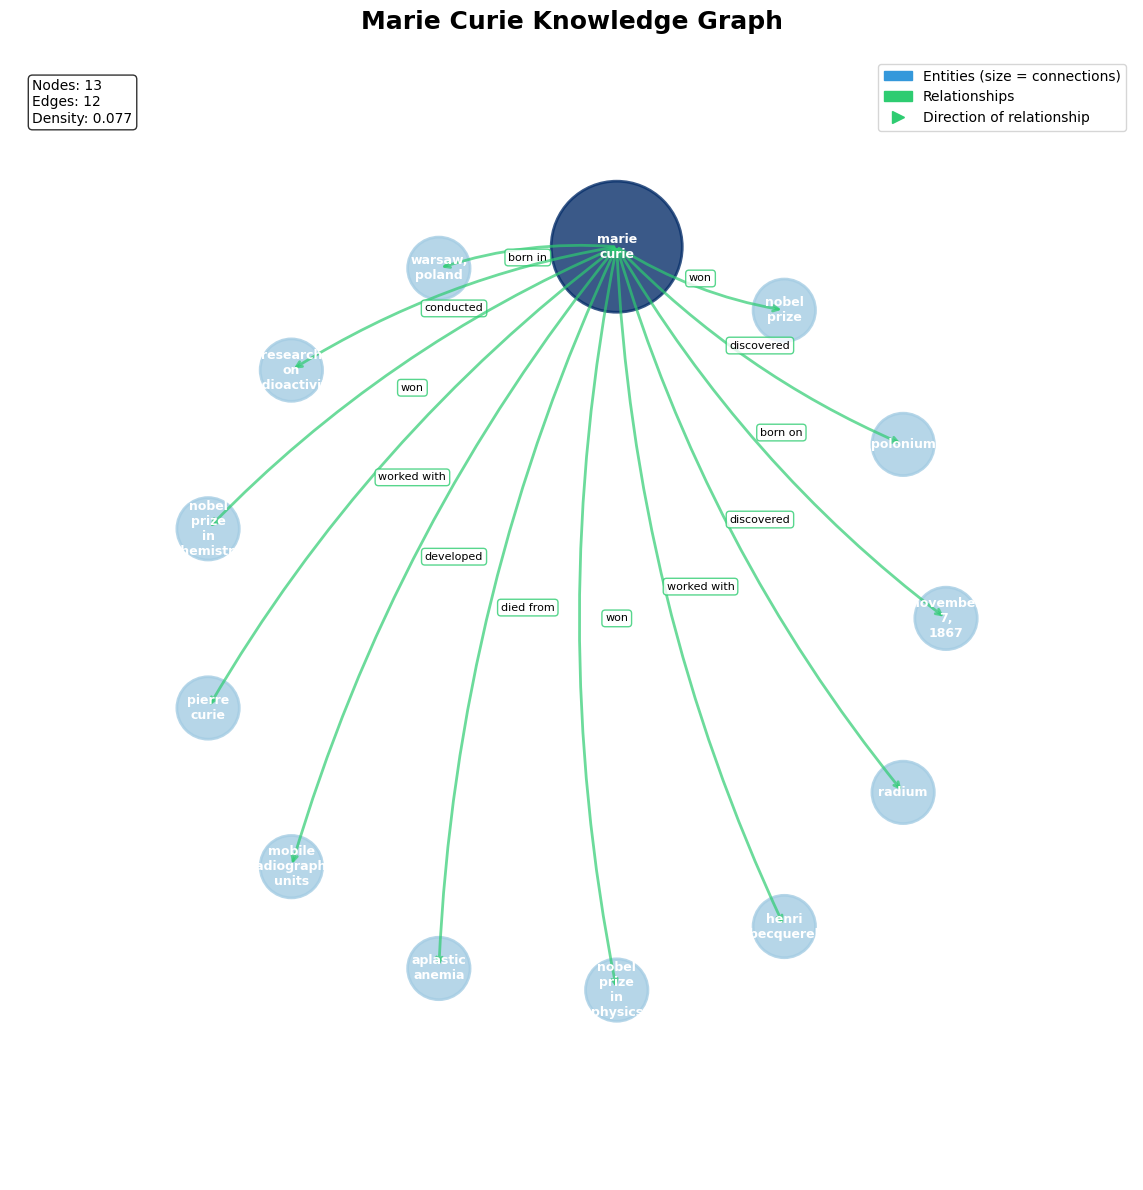


📋 Extracted Triples Summary:


,subject,predicate,object
0,marie curie,born in,"warsaw, poland"
1,marie curie,conducted,research on radioactivity
2,marie curie,discovered,polonium
3,marie curie,discovered,radium
4,marie curie,won,nobel prize
5,marie curie,won,nobel prize in physics
6,marie curie,won,nobel prize in chemistry
7,marie curie,developed,mobile radiography units
8,marie curie,died from,aplastic anemia
9,marie curie,born on,"november 7, 1867"


KNOWLEDGE GRAPH PIPELINE COMPLETE!


In [71]:
print("FINAL KNOWLEDGE GRAPH VISUALIZATION")

if 'knowledge_graph' in locals() and knowledge_graph.number_of_nodes() > 0:
    print(f"📊 Graph Statistics:")
    print(f"   • Total Entities (Nodes): {knowledge_graph.number_of_nodes()}")
    print(f"   • Total Relationships (Edges): {knowledge_graph.number_of_edges()}")
    print(f"   • Graph Density: {nx.density(knowledge_graph):.4f}")
    print()
    
    create_static_graph_plot(knowledge_graph, normalized_triples)
    
    print("\n📋 Extracted Triples Summary:")
    if 'normalized_triples' in locals() and normalized_triples:
        df_final = pd.DataFrame(normalized_triples)
        display(df_final[['subject', 'predicate', 'object']])
    else:
        print("No triples data available.")
        
else:
    print("❌ No graph data found. Please run the extraction pipeline first.")

print("KNOWLEDGE GRAPH PIPELINE COMPLETE!")

In [ ]:
# for ipycytoscape if working
if cyto_widget:
    print("Displaying interactive graph widget below...")
    print("Interact: Zoom (scroll), Pan (drag background), Move Nodes (drag nodes), Hover for details.")
    display(cyto_widget)
else:
    print("No widget to display.")

# Add a clear separator
print("\n" + "-" * 25 + "\nEnd of Visualization Step." + "\n" + "-" * 25)

Displaying interactive graph widget below...
Interact: Zoom (scroll), Pan (drag background), Move Nodes (drag nodes), Hover for details.


CytoscapeWidget(cytoscape_layout={'name': 'cose', 'nodeRepulsion': 4000, 'nodeOverlap': 40, 'idealEdgeLength':…


-------------------------
End of Visualization Step.
-------------------------


# Major Learning and error troubleshooting 

##### The `jupyter-cytoscape` module isn't properly registered in Jupyter environment. This is a common issue in VS Code.

I tried installing and enabling the widgets extension which are for classic jupyter notebook, but still the rendering issues persisted.

The issue is that `jupyter-cytoscape` doesn't exist as a separate package. The correct package is `ipycytoscape`.
Even if you install the `ipycytoscape` package, it doesnt ensure or guarentee that the visuals are going to work.

just like in this case, i had to settle down with static visualization using matplotlib of Knowledge Graph. 

Even though we have used matplotlib as our visualization tool (static), i have added the cells that corresponds with the classic Jupyter Environment if you're Jupyper labs user. 

### Step 11: Conclusion and Next Steps

we have now completed the pipeline with :
1.  Setting libraries and LLM connection.
2.  Defining and chunking input text, visualizing intermediate steps.
3.  Defining detailed prompts for the LLM.
4.  Iterated through chunks (demonstrated with one), showing raw LLM output, parsed JSON, and extracted triples for each.
5.  Aggregated, normalized, and de-duplicated triples, showing the results.
6.  Built the `networkx` graph step-by-step, showing its growth.
7.  Converted data and visualized the final interactive knowledge graph by using `matplotlib` directly in the notebook.

This detailed breakdown should make the transformation from unstructured text to a structured, visual knowledge graph much clearer.

**Potential Improvements and Further Exploration:**

*   **Run Full Loop:** Execute the LLM extraction and normalization across *all* chunks for a complete graph.

*   **Advanced Normalization:** Implement entity linking or relationship clustering.

*   **Error Handling:** Add retries for LLM calls, better handling of persistent chunk failures.

*   **Prompt Tuning:** Experiment with different models, prompts, and parameters.

*   **Evaluation:** Assess the quality of extracted triples (Precision/Recall).

*   **Richer Visualization:** Use node types for colors/shapes, add community detection coloring, implement more interactive features using ipycytoscape callbacks.

*   **Graph Analysis:** Apply `networkx` algorithms (centrality, paths, etc.).

*   **Persistence:** Store results in a graph database (Neo4j, etc.).